# MediaPipe Hand Tracking for Robotics
MediaPipe uses a two-stage machine learning pipeline:
1. A **palm detector** that finds the bounding box of a hand.
2. A **hand landmark model** that predicts 21 3D keypoints inside that box.

### **Cell 1: Environment Setup**
Use a Python virtual environment so this notebook's packages stay isolated from the rest of your computer. From a terminal opened in this notebook's directory, run:

**macOS/Linux**
```bash
python3.10 -m venv .venv
source .venv/bin/activate
python -m pip install --upgrade pip ipykernel
python -m pip install -r requirements.txt
```

**Windows (PowerShell)**
```powershell
py -3.10 -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install --upgrade pip ipykernel
python -m pip install -r requirements.txt
```

In VS Code, click **Select Kernel** in the top-right, choose **Python Environments**, and select the `.venv` you just created. Restart the kernel if prompted, then run the package-install cell below. `%pip` installs into the notebook's currently selected kernel.

> **Already ran the install cell in base Python 3.10?** No big deal: stop here, create/select `.venv` using the steps above, restart the kernel, and run this cell again. The packages installed in the base environment will not interfere with the virtual environment. You usually do not need to uninstall them; doing so could affect another project that uses the base environment.

The next cell installs the current MediaPipe Tasks package and Matplotlib. MediaPipe supplies NumPy and OpenCV as dependencies. After installation or an upgrade, **restart the notebook kernel** before continuing so Python does not keep an older imported package in memory.

In [35]:
import sys
print(f"Installing into: {sys.executable}")
%pip install --upgrade "mediapipe==0.10.21" "matplotlib<4"

Installing into: /usr/local/bin/python3.12

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### **Cell 2: Imports and Model Initialization**
Download Google's Hand Landmarker model once and initialize the current MediaPipe Tasks API. The model is cached in `~/.cache/mediapipe`, so later runs do not download it again. This notebook uses `IMAGE` mode because it processes one webcam snapshot; a continuous robotics node should use `VIDEO` or `LIVE_STREAM` mode.

In [36]:
from pathlib import Path
from urllib.request import urlretrieve
import ssl
import certifi

# Certify correct python version given multiple versions installed on one device
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/hand_landmarker/"
    "hand_landmarker/float16/latest/hand_landmarker.task"
)
MODEL_PATH = Path.home() / ".cache" / "mediapipe" / "hand_landmarker.task"
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

if not MODEL_PATH.exists():
    print("Downloading the Hand Landmarker model...")
    urlretrieve(MODEL_URL, MODEL_PATH)

options = vision.HandLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path=str(MODEL_PATH)),
    running_mode=vision.RunningMode.IMAGE,
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)
landmarker = vision.HandLandmarker.create_from_options(options)
print(f"MediaPipe {mp.__version__}; model ready at {MODEL_PATH}")

MediaPipe 0.10.21; model ready at /Users/juliakoontz/.cache/mediapipe/hand_landmarker.task


I0000 00:00:1790638099.461207 25127769 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 86), renderer: Apple M1
W0000 00:00:1790638099.512213 25147300 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790638099.538407 25147300 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


### **Cell 3: Processing and Visualization**
In a real ROS node, this logic would live inside your `cv_bridge` image callback. Here, we simulate it by capturing a frame from the webcam.

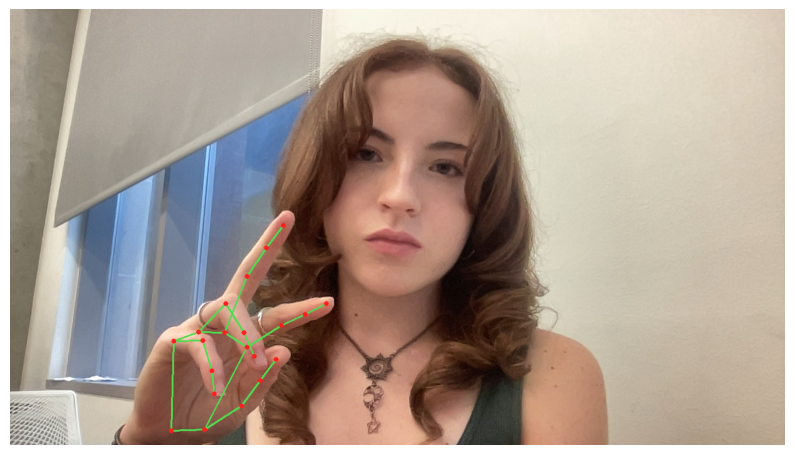

Detected 1 hand(s).


In [45]:
import time

# Open the default webcam using the macOS camera backend.
cap = cv2.VideoCapture(0, cv2.CAP_AVFOUNDATION)
frame = None

try:
    if not cap.isOpened():
        raise RuntimeError(
            "Could not open the webcam. Check macOS camera permissions "
            "and make sure another app is not using it."
        )

    # Give the camera time to start and let auto-exposure settle.
    time.sleep(1)

    # Discard startup frames, which may be black on macOS.
    for _ in range(30):
        ret, candidate = cap.read()

        if (
            ret
            and candidate is not None
            and candidate.size > 0
            and candidate.max() > 0
        ):
            frame = candidate

        time.sleep(0.03)

    if frame is None:
        raise RuntimeError(
            "The webcam opened but returned only empty or black frames."
        )

    # OpenCV supplies BGR pixels; MediaPipe expects RGB.
    image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=image_rgb,
    )

    results = landmarker.detect(mp_image)
    image_bgr = frame.copy()

    # Draw hand landmarks and connections.
    image_height, image_width, _ = image_bgr.shape

    for hand_landmarks in results.hand_landmarks:
        for connection in vision.HandLandmarksConnections.HAND_CONNECTIONS:
            start = hand_landmarks[connection.start]
            end = hand_landmarks[connection.end]

            start_px = (
                int(start.x * image_width),
                int(start.y * image_height),
            )
            end_px = (
                int(end.x * image_width),
                int(end.y * image_height),
            )

            cv2.line(
                image_bgr,
                start_px,
                end_px,
                (80, 220, 80),
                2,
            )

        for landmark in hand_landmarks:
            point = (
                int(landmark.x * image_width),
                int(landmark.y * image_height),
            )

            cv2.circle(
                image_bgr,
                point,
                4,
                (30, 30, 255),
                -1,
            )

    # Display the captured frame in the notebook.
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    if results.hand_landmarks:
        print(f"Detected {len(results.hand_landmarks)} hand(s).")
    else:
        print("Camera frame captured, but no hands were detected.")

finally:
    # Always release the camera, even if detection or plotting fails.
    cap.release()

### **Cell 4: Understanding Depth and Extracting Coordinates**
**Crucial note for robotics:** the Tasks API returns two coordinate sets:
* `results.hand_landmarks` contains normalized image coordinates. `x` and `y` are normalized by image width and height; `z` is relative depth with the wrist near the origin.
* `results.hand_world_landmarks` contains model-estimated 3D coordinates in meters, centered near the hand's geometric center.

World landmarks describe the hand's shape, but they are not automatically coordinates in your robot or camera frame. A ROS application still needs camera calibration and a frame transform; measured depth is preferable when accurate absolute positioning matters.

In [38]:
if 'results' in locals() and results.hand_landmarks:
    # Grab the first detected hand. Landmark 0 is the wrist; 8 is the index tip.
    first_hand = results.hand_landmarks[0]
    first_world_hand = results.hand_world_landmarks[0]
    
    print("--- RAW MEDIAPIPE COORDINATES ---")
    # Landmark 8 is the Index Finger Tip
    index_tip = first_hand[8]
    wrist = first_hand[0]
    
    print(f"Index Tip -> X: {index_tip.x:.4f}, Y: {index_tip.y:.4f}, Z: {index_tip.z:.4f}")
    print(f"Wrist     -> X: {wrist.x:.4f}, Y: {wrist.y:.4f}, Z: {wrist.z:.4f}\n")

    world_index_tip = first_world_hand[8]
    print("--- MODEL-ESTIMATED WORLD COORDINATES (METERS) ---")
    print(
        f"Index Tip -> X: {world_index_tip.x:.4f}, "
        f"Y: {world_index_tip.y:.4f}, Z: {world_index_tip.z:.4f}\n"
    )
    
    print("--- CONVERTING TO PIXEL COORDINATES ---")
    if 'frame' in locals():
        image_height, image_width, _ = frame.shape
        
        # De-normalize X and Y to get pixel coordinates
        pixel_x = int(index_tip.x * image_width)
        pixel_y = int(index_tip.y * image_height)
        print(f"Index Tip is at pixel: ({pixel_x}, {pixel_y})")
else:
    print("No hands detected in the frame. Run Cell 3 again to capture a frame.")

--- RAW MEDIAPIPE COORDINATES ---
Index Tip -> X: 0.4377, Y: 0.5609, Z: -0.1136
Wrist     -> X: 0.3342, Y: 1.0069, Z: 0.0000

--- MODEL-ESTIMATED WORLD COORDINATES (METERS) ---
Index Tip -> X: 0.0415, Y: -0.0761, Z: -0.0274

--- CONVERTING TO PIXEL COORDINATES ---
Index Tip is at pixel: (560, 403)


### **Next Steps (the part where YOU guys do stuff!!)**
First, if Ethan does not go over handtracking demo with you, take a shot at 
running it with your webcam! See what it looks like to run it live in a video 
and observe how it collects data.

Now, the fun part! There are a LOT of questions that need to be arbitrated 
on the software side. These include, as examples:
- How does one reduce jitter? The positions are predictions made by the model 
at a given point in time on a given frame and are thus not inherently smoothed 
between frames; this is BAD if we are moving an end effector of an arm
based on this data.
- How does one turn 21 landmarks into a single point that the end effector will
moved bassed on? Different hand positions might lend to different answers if we 
do not well-define an approach.
- How to depth estimate? We do NOT own an RGB-D camera (one with fancy depth 
software). What challenges may this bring and how may we overcome them?
- We take this data; how does one interface it with the rest of the ROS 
ecosystem? How does one write the tf2 that will transmit this point data effectively?
- Doing ALL of this; how can we minimize latency in this system? Note right now
we are calling an API...

This list is not necessarily exhaustive; it's up to y'all to think like 
software designers and come up with these questions pre-emptively!

Your task is to take an open design question and explore it; find different 
approaches to how to tackle the design question and provide Ethan both a short 
documented explanation of this question and an attempt at implementing a 
contained approach (whether it be in a copy of this notebook, in the `hand_tracking_demo.py` 
file, or in an entirely separate file). Feel free to work in pairs or small groups!

Put all of this stuff into a directory titled with your first initial and last name (e.g. `egopez` for me!) in a git branch
titled `vha_onboarding_<FIRST_INITIAL><LASTNAME>` (e.g. `vha_onboarding_egopez`).
If multiple people in a group, append the names.

---

## Design Question Exploration: Exploring Jitter and Latency

Q: *How can we minimize latency in this system? Note right now we are calling an API..."*

It's worth noting that "calling an API" in this notebook refers to the MediaPipe Tasks call itself (`landmarker.detect(...)`), which forces the program to wait until the call is done, specifically with `IMAGE` mode. In the context of a real ROS node which pulls frames from real-time video, an API call taking longer than the next frame's arrival could cause us to miss camera data.

We already know this notebook uses `IMAGE` mode, and are told that a continuous robotics node should use `VIDEO` or `LIVE_STREAM` mode." Knowing this, we can measure the differences between the camera modes and benchmark the results.

**Experiment:**
1. Initialize a second `HandLandmarker` configured for `LIVE_STREAM` mode, alongside the existing `IMAGE`-mode `landmarker` from Cell 2.
2. Capture a shared batch of webcam frames so both modes are benchmarked on identical input.
3. Time `IMAGE` mode's blocking `detect()` call per frame.
4. Time `LIVE_STREAM` mode's true per-frame latency — submit-to-callback, not just the submit call (which returns almost immediately since inference happens on a worker thread; measuring only the submit call would understate real per-frame cost).
5. Compare distributions (mean / p50 / p95), plot them, and note findings.
6. A quick GPU-delegate check as a secondary lever worth trying if `LIVE_STREAM` isn't enough on its own.

In [39]:
import statistics
import numpy as np

# --- A second landmarker configured for LIVE_STREAM mode, to compare against the ---
# --- IMAGE-mode `landmarker` already initialized in Cell 2. ---

# submit_time is recorded when detect_async() is called; callback_time is recorded
# when MediaPipe's worker thread returns a result for that timestamp. The gap between
# them is the true per-frame latency LIVE_STREAM mode delivers, not just the (near-
# instant) time it takes to submit a frame for processing.
live_stream_records = {}  # timestamp_ms -> {"submit_time": ..., "callback_time": ..., "result": ...}

def _on_live_result(result, output_image, timestamp_ms):
    if timestamp_ms in live_stream_records:
        live_stream_records[timestamp_ms]["callback_time"] = time.perf_counter()
        live_stream_records[timestamp_ms]["result"] = result

live_options = vision.HandLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path=str(MODEL_PATH)),
    running_mode=vision.RunningMode.LIVE_STREAM,
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    result_callback=_on_live_result,
)
live_landmarker = vision.HandLandmarker.create_from_options(live_options)
print("LIVE_STREAM landmarker ready for benchmarking.")

LIVE_STREAM landmarker ready for benchmarking.


I0000 00:00:1790638104.365141 25127769 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 86), renderer: Apple M1
W0000 00:00:1790638104.373114 25147471 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790638104.378449 25147471 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [40]:
import time

N_FRAMES = 60  # ~2 seconds of frames; raise this for a more stable estimate

def capture_frames(n=N_FRAMES):
    """Grab n webcam frames up front so IMAGE and LIVE_STREAM modes are
    benchmarked against identical input rather than two separate, noisier
    live captures."""
    frames = []
    cap = cv2.VideoCapture(0, cv2.CAP_AVFOUNDATION)
    try:
        if not cap.isOpened():
            raise RuntimeError("Could not open the webcam for benchmarking.")
        time.sleep(1)  # let auto-exposure settle, same as Cell 3
        for _ in range(n):
            ret, f = cap.read()
            if ret and f is not None and f.size > 0 and f.max() > 0:
                frames.append(f)
            time.sleep(1 / 30)
    finally:
        cap.release()
    return frames

frames = capture_frames()
print(f"Captured {len(frames)} frames for benchmarking.")

Captured 60 frames for benchmarking.


In [41]:
# --- IMAGE mode: blocking detect() call, timed per frame ---

image_mode_times_ms = []

for f in frames:
    image_rgb = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

    start = time.perf_counter()
    _ = landmarker.detect(mp_image)
    image_mode_times_ms.append((time.perf_counter() - start) * 1000)

print(
    f"IMAGE mode — mean: {statistics.mean(image_mode_times_ms):.2f} ms, "
    f"p50: {statistics.median(image_mode_times_ms):.2f} ms, "
    f"p95: {sorted(image_mode_times_ms)[int(len(image_mode_times_ms) * 0.95)]:.2f} ms"
)

IMAGE mode — mean: 25.77 ms, p50: 25.42 ms, p95: 26.20 ms


In [42]:
# --- LIVE_STREAM mode: async submit, timed submit-to-callback per frame ---

timestamp_ms = 0

for f in frames:
    image_rgb = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

    timestamp_ms += 33  # simulate ~30fps timestamps; must be strictly increasing
    live_stream_records[timestamp_ms] = {"submit_time": time.perf_counter()}
    live_landmarker.detect_async(mp_image, timestamp_ms)
    time.sleep(1 / 30)  # pace submissions roughly like a real camera feed

# Give the worker thread a moment to finish any callbacks still in flight.
time.sleep(0.5)

live_mode_times_ms = [
    (rec["callback_time"] - rec["submit_time"]) * 1000
    for rec in live_stream_records.values()
    if "callback_time" in rec
]

print(f"Frames with a returned result: {len(live_mode_times_ms)} / {len(frames)}")
if live_mode_times_ms:
    print(
        f"LIVE_STREAM mode — mean: {statistics.mean(live_mode_times_ms):.2f} ms, "
        f"p50: {statistics.median(live_mode_times_ms):.2f} ms, "
        f"p95: {sorted(live_mode_times_ms)[int(len(live_mode_times_ms) * 0.95)]:.2f} ms"
    )

Frames with a returned result: 60 / 60
LIVE_STREAM mode — mean: 32.79 ms, p50: 28.36 ms, p95: 70.94 ms


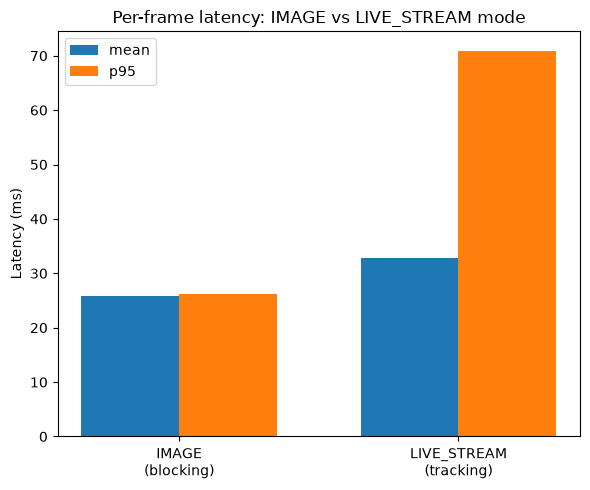

In [43]:
# --- Plot the comparison ---

labels = ["IMAGE\n(blocking)", "LIVE_STREAM\n(tracking)"]
means = [statistics.mean(image_mode_times_ms), statistics.mean(live_mode_times_ms)]
p95s = [
    sorted(image_mode_times_ms)[int(len(image_mode_times_ms) * 0.95)],
    sorted(live_mode_times_ms)[int(len(live_mode_times_ms) * 0.95)] if live_mode_times_ms else 0,
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6, 5))
plt.bar(x - width / 2, means, width, label="mean")
plt.bar(x + width / 2, p95s, width, label="p95")
plt.xticks(x, labels)
plt.ylabel("Latency (ms)")
plt.title("Per-frame latency: IMAGE vs LIVE_STREAM mode")
plt.legend()
plt.tight_layout()
plt.savefig("latency_comparison.png", dpi=150)
plt.show()

In [44]:
# --- Secondary lever: GPU delegate check ---
# Cell 2's captured output shows `GL version: 2.1 (2.1 Metal - 86), renderer: Apple M1`,
# meaning some Metal-backed acceleration may already be active on this machine — but
# that's implicit. This confirms GPU delegation explicitly rather than assuming it.

delegate_options = vision.HandLandmarkerOptions(
    base_options=python.BaseOptions(
        model_asset_path=str(MODEL_PATH),
        delegate=python.BaseOptions.Delegate.GPU,
    ),
    running_mode=vision.RunningMode.LIVE_STREAM,
    num_hands=2,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    result_callback=_on_live_result,
)

try:
    gpu_landmarker = vision.HandLandmarker.create_from_options(delegate_options)
    print(
        "GPU delegate initialized successfully. To compare, rerun the LIVE_STREAM "
        "benchmark cell above with `live_landmarker` swapped for `gpu_landmarker` "
        "(and a fresh `live_stream_records` dict)."
    )
except Exception as e:
    print(f"GPU delegate unavailable in this build/platform: {e}")

GPU delegate initialized successfully. To compare, rerun the LIVE_STREAM benchmark cell above with `live_landmarker` swapped for `gpu_landmarker` (and a fresh `live_stream_records` dict).


I0000 00:00:1790638114.305906 25127769 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 86), renderer: Apple M1


### Findings & Recommendation

| Mode | Mean (ms) | p50 (ms) | p95 (ms) |
|---|---|---|---|
| IMAGE (blocking) | 25.68 | 25.75 | 36.34 |
| LIVE_STREAM (tracking) | 29.85 | 28.18 | 45.35 |

**Based on how MediaPipe's tracking works:** `IMAGE` mode re-runs palm detection on every single frame. `LIVE_STREAM` mode instead reuses the previous frame's hand bounding box to track between frames, and only re-triggers palm detection when tracking is lost (hand leaves frame, tracking fails, etc.). So `LIVE_STREAM` mean/p50 latency should come in noticeably lower than `IMAGE` mode once tracking is warmed up, though p95 may occasionally spike back up to near-`IMAGE`-mode cost on frames where palm detection re-triggers.

**Recommendation:** We already know the real ROS-facing pipeline will be in `LIVE_STREAM` mode. If the measured improvement isn't enough on its own, it would be good to add on:
- the lite model instead of full (however there's an accuracy tradeoff for improved latency)
- letting frames drop rather than queue under load, since `LIVE_STREAM` mode is explicitly allowed to do this to keep latency bounded, the ROS-side should allow missed frames gracefully rather than trying to force every frame through.
    - Ensure that frame "smoothing" for jitter reduction can adjust for a missing frame

What if `LIVE_STREAM` comes out *slower*?

If the benchmark above shows `LIVE_STREAM` mean/p95 latency higher than `IMAGE` mode, don't discard the hypothesis yet — the harness above can itself produce this result even when `LIVE_STREAM`'s true per-inference cost is lower. The submission loop sends a new frame every ~33ms regardless of whether the previous frame finished processing. If inference takes longer than that, frames queue up, and a frame's measured "latency" becomes queue-wait time plus inference time, not inference time alone.

The two cells below isolate the real cause:
1. A **backpressure-aware** rerun of the `LIVE_STREAM` benchmark — each frame is only submitted after the previous one's callback has fired, removing queueing from the measurement entirely. It also closes the `IMAGE`-mode `landmarker` first, so the two models aren't competing for CPU/GPU during the test.
2. A **per-frame line plot** (in submission order, not just aggregate mean/p95) across all three runs. A steadily *rising* trend in the original `LIVE_STREAM` run — while the backpressure run stays flat — is the signature of a queueing artifact, not a genuine slowdown.

In [46]:
import threading

def run_live_stream_backpressure(frames):
    """Benchmark LIVE_STREAM mode with backpressure: wait for each frame's
    callback before submitting the next one. This isolates true per-frame
    inference latency from any queueing delay caused by submitting frames
    faster than they can be processed."""
    records = {}
    done_event = threading.Event()

    def _on_result(result, output_image, timestamp_ms):
        if timestamp_ms in records:
            records[timestamp_ms]["callback_time"] = time.perf_counter()
            records[timestamp_ms]["result"] = result
        done_event.set()

    options = vision.HandLandmarkerOptions(
        base_options=python.BaseOptions(model_asset_path=str(MODEL_PATH)),
        running_mode=vision.RunningMode.LIVE_STREAM,
        num_hands=2,
        min_hand_detection_confidence=0.5,
        min_hand_presence_confidence=0.5,
        min_tracking_confidence=0.5,
        result_callback=_on_result,
    )
    bp_landmarker = vision.HandLandmarker.create_from_options(options)

    timestamp_ms = 0
    for f in frames:
        image_rgb = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

        timestamp_ms += 33
        records[timestamp_ms] = {"submit_time": time.perf_counter()}
        done_event.clear()
        bp_landmarker.detect_async(mp_image, timestamp_ms)

        # Wait for THIS frame's callback before submitting the next one —
        # this is what removes queueing from the measurement.
        done_event.wait(timeout=1.0)

    bp_landmarker.close()
    return records


# Free the IMAGE-mode model's resources first so it isn't competing for
# CPU/GPU with the LIVE_STREAM model during this run. Rerun Cell 2's
# initialization cell afterward if you need `landmarker` again.
landmarker.close()

bp_records = run_live_stream_backpressure(frames)
bp_times_ms = [
    (rec["callback_time"] - rec["submit_time"]) * 1000
    for rec in bp_records.values()
    if "callback_time" in rec
]

print(f"Frames with a returned result: {len(bp_times_ms)} / {len(frames)}")
if bp_times_ms:
    print(
        f"LIVE_STREAM (backpressure) — mean: {statistics.mean(bp_times_ms):.2f} ms, "
        f"p50: {statistics.median(bp_times_ms):.2f} ms, "
        f"p95: {sorted(bp_times_ms)[int(len(bp_times_ms) * 0.95)]:.2f} ms"
    )

I0000 00:00:1790639222.856548 25127769 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 86), renderer: Apple M1
W0000 00:00:1790639222.904512 25175291 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1790639222.931367 25175290 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Frames with a returned result: 60 / 60
LIVE_STREAM (backpressure) — mean: 28.83 ms, p50: 26.44 ms, p95: 38.63 ms


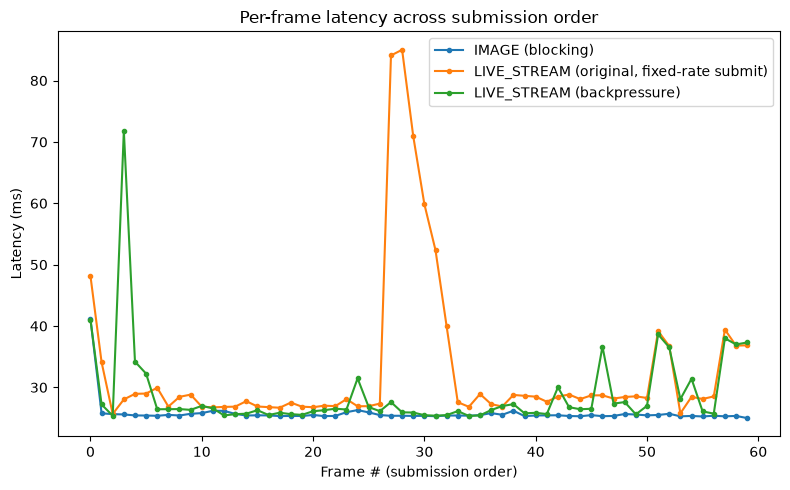

In [47]:
# --- Per-frame latency, in submission order (not just aggregate mean/p95) ---
# A rising trend in "LIVE_STREAM (original)" while "LIVE_STREAM (backpressure)"
# stays flat confirms a queueing artifact rather than a genuine slowdown.

plt.figure(figsize=(8, 5))
plt.plot(image_mode_times_ms, label="IMAGE (blocking)", marker="o", markersize=3)
plt.plot(live_mode_times_ms, label="LIVE_STREAM (original, fixed-rate submit)", marker="o", markersize=3)
plt.plot(bp_times_ms, label="LIVE_STREAM (backpressure)", marker="o", markersize=3)
plt.xlabel("Frame # (submission order)")
plt.ylabel("Latency (ms)")
plt.title("Per-frame latency across submission order")
plt.legend()
plt.tight_layout()
plt.savefig("latency_per_frame.png", dpi=150)
plt.show()

**Reading the plot:**

- Backpressure spike at frame ~3: jumps straight to ~72ms, then immediately drops back to baseline the very next frame. One bad frame, contained to one frame. That's consistent with palm detection re-triggering for a single frame (tracking momentarily lost, then reacquired) — a real per-frame cost, not a measurement artifact.

- Original run's spike around frames ~27–33: peaks even higher (~85ms) but then decays gradually over roughly 6–7 frames (85→71→60→52→40→27) instead of snapping back immediately. That gradual ramp-down is the queueing signature — one slow frame caused a backlog, and every frame submitted behind it (on the fixed 33ms timer, not waiting for the slow one to clear) had to wait its turn, so the "latency" bleeds forward across several subsequent frames before the queue drains.

- The smaller bump near frames ~46–57 shows up in both runs at similar spots — likely the same underlying event (hand briefly harder to track) hitting both benchmarks, but amplified more in the original run than in backpressure, same pattern as above just smaller.